In [2]:
import time
import h5py
import numpy as np
import tifffile
import tomopy
import matplotlib.pyplot as plt

from tomoDataClass import tomoData

# PROJ_PATH  = '/Users/levihancock/Documents/Work/Code/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg59_ds4x_aligned_20260505-121404.tif'
PROJ_PATH = '/home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/bestNotebookAlignedProjections(4xds).tiff'

# ANGLE_PATH = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
ANGLE_PATH = '/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5'


projs = tifffile.imread(PROJ_PATH).astype(np.float32)  # (n_angles, ny, nx)
with h5py.File(ANGLE_PATH) as f:
    angles = f['angles'][...] * np.pi / 180
    angles = angles - np.mean(angles)  # Shift angles to be centered around 0

print(f'Projections : {projs.shape}  [{projs.min():.3f}, {projs.max():.3f}]')
print(f'Angles      : {len(angles)}  [{np.degrees(angles.min()):.1f}°, {np.degrees(angles.max()):.1f}°]')

center = tomopy.find_center_vo(projs)
print(f'Rotation center: {center:.2f} px')

tomo = tomoData(projs, angles)

No usable GPU detected — running CPU-only.
Projections : (556, 146, 452)  [-5.564, 0.348]
Angles      : 558  [-65.4°, 65.4°]
Rotation center: 225.00 px




Using CPU-based reconstruction. Algorithm:  gridrec


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

Reconstruction completed.


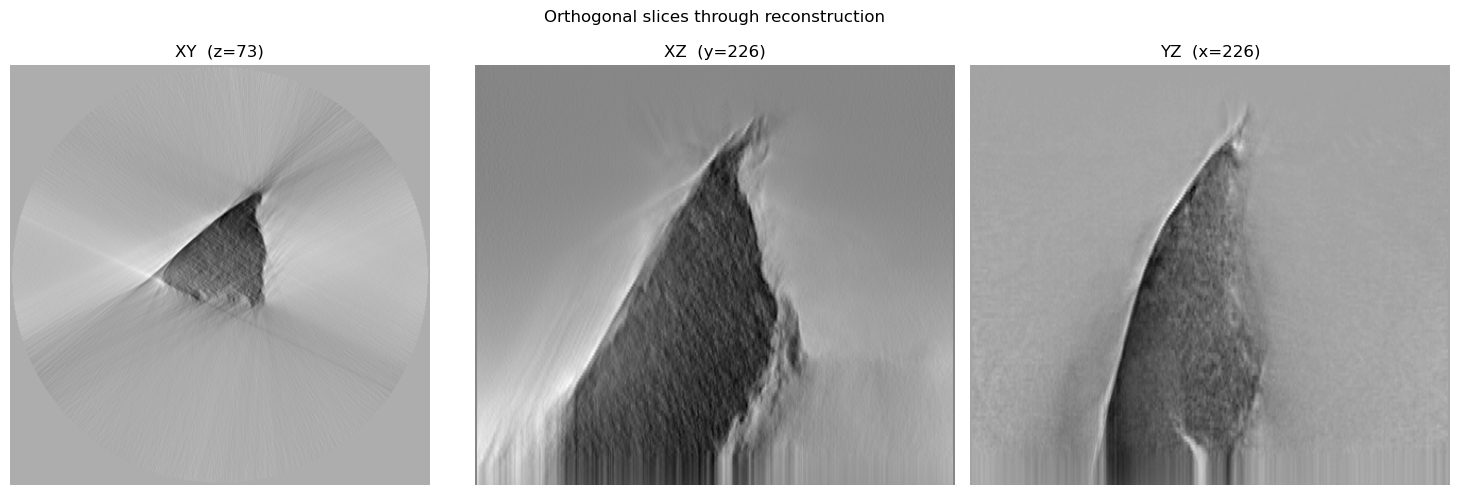

In [3]:

tomo.reconstruct(algorithm='gridrec')
tomo.displayReconOrthogonalSlices()

In [4]:
tomo.makeNotebookReconMovie()

Output()

Applying Kovacik filter:   0%|          | 0/146 [00:00<?, ?it/s]

Applying Kovacik filter: 100%|██████████| 146/146 [00:11<00:00, 13.22it/s]


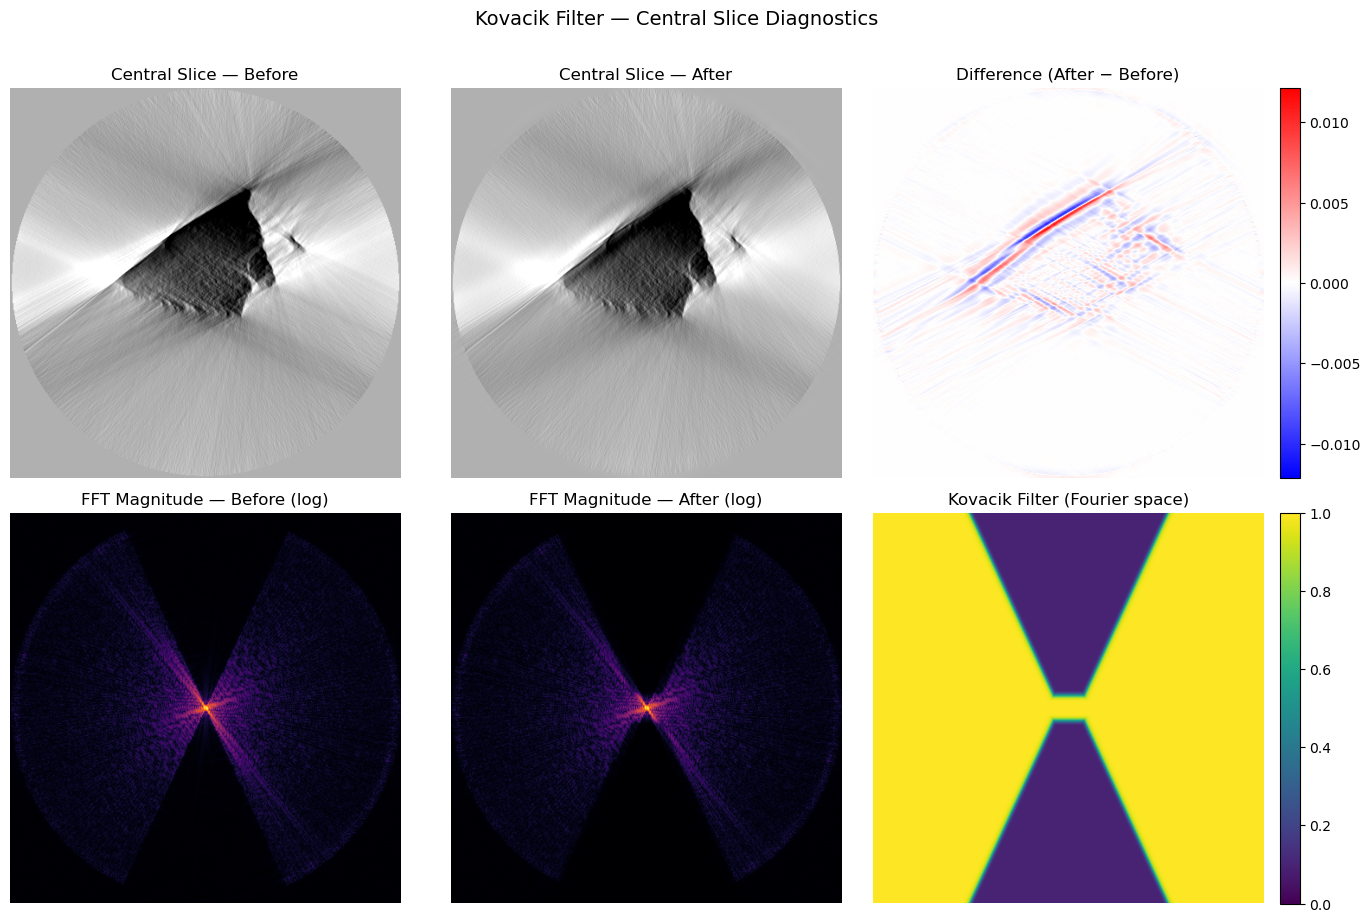

Kovacik filter applied.


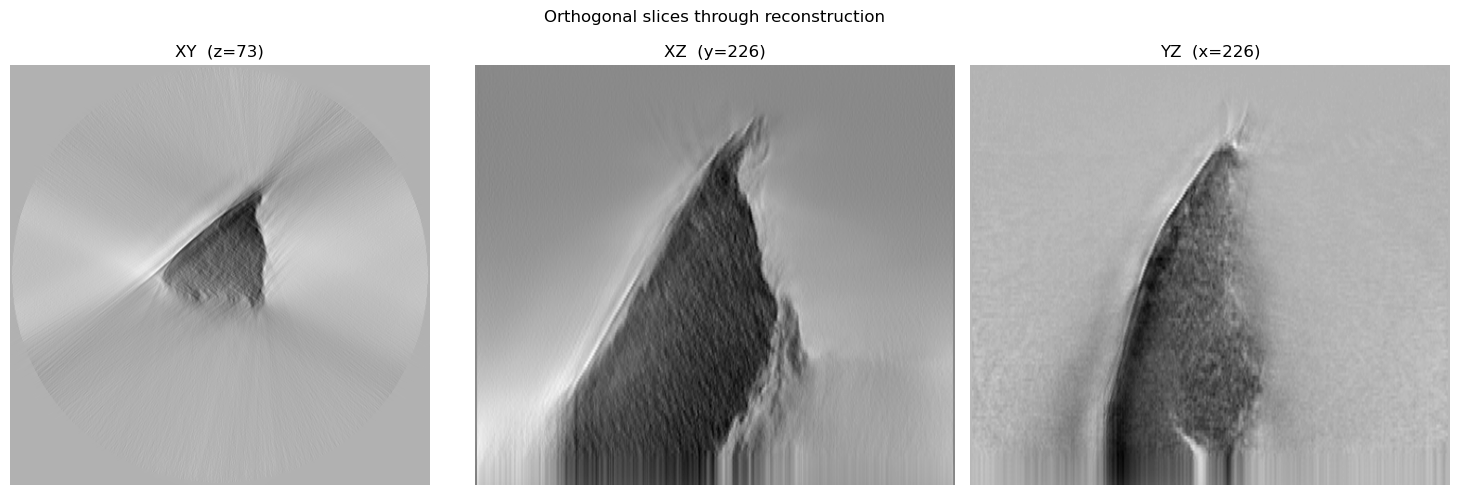

Output()

In [6]:
tomo.kovacik_filter(
    mwr_length=10,             # tighten the ramp
    mwr_order=4,               # steep roll-off → stays near the boundary, preserves interior signal
    mwr_wmin=0.1,              # slightly less aggressive than 0.05
    cs_cutoff=15,               # keep
    cs_order=4,                # keep
    plot=True,
    plotSlice=96
)
tomo.displayReconOrthogonalSlices()
tomo.makeNotebookReconMovie()